**Exercise 3 - Logistic regression [10 pt]**

---

This exercise will be about logistic regression. Given a set of data points and classes your task will be to implement the functions that calculate the model $\theta$ parameters to fit the data and infer the class for each point set.

In [1]:
# import libraries used during this exercise
import pandas as pd
import numpy as np
from mlrcv.core import *

%matplotlib inline

In this exercise we will use a toy dataset with $x_1$, $x_2$ and the $y$ (*class*) values, where the point ($x_1$,$x_2$) is the observed data that should be used to predict the $y$ class value.

In [ ]:
# Dataset read
df = pd.read_csv('data/logistic_regression.csv')
x_bin = df.drop(columns=['class']).values
y_bin = df['class'].values
y_bin = y_bin[:, None]

plot_data_binary(x_bin, y_bin)

**3.1 Logistic regression \[5 pt\]**

---

Given the loaded dataset $x=(x_1,x_2)$ and $y$, you should implement the functions in the `mlrcv/logistic_regression.py` and `mlrcv/utils.py` files to calculate the model $\theta$ parameters vector that will fit the data. 

The following functions should be implemented in `mlrcv/utils.py` file:
- `sigmoid`: the activation function used during training [1pt]

Then, you should implement the functions from the class *LogisticRegression* in `mlrcv/logistic_regression.py`:
- `train_model`: train the model [1pt]
- `first_derivative`: compute the gradients (derivatives) to update the $\theta$ parameters [1pt]
- `predict_y`: [1pt]
- `eval`: [1pt]

(**Note:** The *plot_regression_binary* function is already implemented on the *core.py* file.)

In [3]:
from mlrcv.logistic_regression import *
from mlrcv.utils import *

# fix the random seed
np.random.seed(42)

x_bin_train, y_bin_train, x_bin_val, y_bin_val = split_data(x_bin, y_bin)

Model accuracy: 98.00


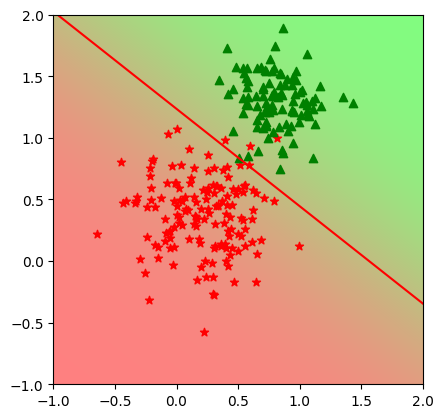

In [4]:
model = LogisticRegression(learning_rate=.010000, epochs=10)
model.train_model(x_bin_train, y_bin_train)
print('Model accuracy: %.2f' % model.eval(x_bin_val, y_bin_val))

plot_regression_binary(x_bin_val, y_bin_val, model)

You are expected to get around 97% of accuracy here. You may tune the epochs and learning rate to get a feeling of the hyperparameters tuning.

**3.2 Multi-class logistic regression (Softmax regression) \[5 pt\]**

---

In some cases our data may have more than two classes, for that we can represent the logistic regression as a multi-class formulation. In this second task you should implement the class *MultiClassLogisticRegression* to fit your model in this new dataset with 3 classes.

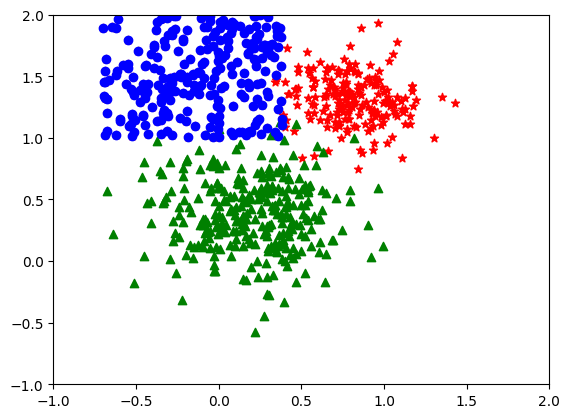

In [5]:
# Dataset read
df = pd.read_csv('data/logistic_regression_multi_class.csv')
x_multi = df.drop(columns=['class']).values
y_multi = pd.get_dummies(df['class']).values

num_class = 3

plot_data_multi_class(x_multi, y_multi)

# implemented, already split our data here
x_multi_train, y_multi_train, x_multi_val, y_multi_val = split_data(x_multi, y_multi)

As in the previous tasks, you should implement the four functions inside the *MultiClassLogisticRegression* class in `mlrcv/logistic_regression.py`, but now for the multi-class case:
- `train_model`: train the model [1pt]
- `first_derivative`: compute the gradients (derivatives) to update the $\theta$ parameters [1pt]
- `predict_y`: [1pt]
- `eval`: [1pt]

And in this case, implement the `softmax` function as well in `mlrcv/utils.py` [1pt]. 

(**Note:** The *plot_regression_multi_class* function is already implemented.)

Model acc:  97.33333333333334


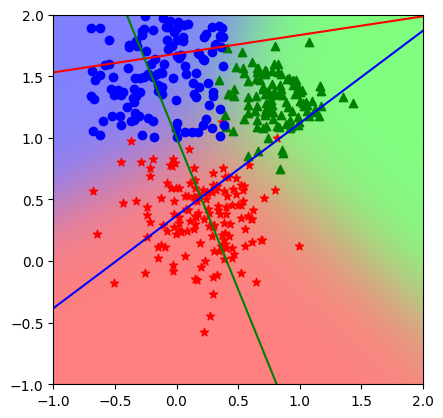

In [6]:
from mlrcv.logistic_regression import *
from mlrcv.utils import *

model = MultiClassLogisticRegression(learning_rate=.01, epochs=20)
model.train_model(x_multi_train, y_multi_train)
print('Model acc: ', model.eval(x_multi_val, y_multi_val))

plot_regression_multi_class(x_multi_val, y_multi_val, model)

You are expected to get around 95% of accuracy here. You may tune the epochs and learning rate to get a feeling of the hyperparameters tuning.

**Assignment Submission**

---

To submit your assignment, run the following command from the root of the repository (For Linux and MacOS):

```bash
sh submit.sh
```

For Windows, please use `submit.bat` or try git bash.

**Check That You Actually Submitted**

You can check that your submission worked in several ways:

1. There is a new line in the file submission.txt with current date and time.
2. There is a new commit in your git history with the title "Submission".